In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#F8F9FA",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})
COLORS = ["#4C72B0", "#55A868", "#DD8452", "#C44E52", "#9467BD", "#8C564B"]


In [4]:
from google.colab import drive
drive.mount('/content/drive')
PATH = "/content/drive/MyDrive/ML Project/"
save_dir = "/content/drive/MyDrive/ML Project/saved_objects/"
os.makedirs(save_dir, exist_ok=True)

print("Save directory:", save_dir)

assessments         = pd.read_csv(PATH + "assessments.csv")
courses             = pd.read_csv(PATH + "courses.csv")
studentAssessment   = pd.read_csv(PATH + "StudentAssesments.csv")
studentInfo         = pd.read_csv(PATH + "studentInfo.csv")
studentRegistration = pd.read_csv(PATH + "studentRegistration.csv")
studentVle          = pd.read_csv(PATH + "studentVle.csv")
vle                 = pd.read_csv(PATH + "vle.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save directory: /content/drive/MyDrive/ML Project/saved_objects/


# 1 ) Preprocessing:

In [5]:
print(assessments.shape)
print(courses.shape)
print(studentAssessment.shape)
print(studentInfo.shape)
print(studentRegistration.shape)
print(studentVle.shape)
print(vle.shape)
studentVle.head()

(206, 6)
(22, 3)
(163912, 5)
(32593, 11)
(32593, 5)
(10655280, 6)
(6364, 6)


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [6]:
studentVle_full = studentVle.merge( vle,  on=["id_site", "code_module", "code_presentation"] )
studentVle_agg = studentVle_full.groupby(["code_module", "code_presentation", "id_student"]
).agg(
    total_clicks=("sum_click", "sum"),
    avg_clicks=("sum_click", "mean"),
    interaction_days=("date", "nunique"),
    total_interactions=("id_site", "count"),
    unique_activity_types=("activity_type", "nunique")
).reset_index()

In [7]:
df = studentAssessment.merge(assessments, on="id_assessment", how="left")
df = df.merge( studentInfo,on=["id_student", "code_module", "code_presentation"], how="left")
df = df.merge( courses,on=["code_module", "code_presentation"],how="left")
df = df.merge(studentRegistration,on=["id_student", "code_module", "code_presentation"],how="left")
df = df.merge(studentVle_agg,on=["id_student", "code_module", "code_presentation"],how="left")

In [8]:
print(df.shape)
print(df.isnull().sum())
print(df.info())

(163912, 26)
id_assessment                   0
id_student                      0
date_submitted                  0
is_banked                       0
score                           0
code_module                     0
code_presentation               0
assessment_type                 0
date                            0
weight                          0
gender                          0
region                          0
highest_education               0
imd_band                        0
age_band                        0
num_of_prev_attempts            0
studied_credits                 0
disability                      0
module_presentation_length      0
date_registration               0
date_unregistration             0
total_clicks                  158
avg_clicks                    158
interaction_days              158
total_interactions            158
unique_activity_types         158
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163912 entries, 0 to 163911
Data columns

In [9]:
for col in ["score", "date_submitted", "date_registration",
            "date_unregistration", "num_of_prev_attempts", "studied_credits"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [10]:
for col in df.select_dtypes(include='object').columns:
    weird_values = df[col][~df[col].astype(str).str.match(r'^[a-zA-Z0-9\s\-\.%]+$')]

    if not weird_values.empty:
        print(f"\nWeird values in column: {col}")
        print(weird_values.unique()[:10])


Weird values in column: date
['?']

Weird values in column: imd_band
['?']

Weird values in column: age_band
['55<=']


In [11]:
df.replace("?", np.nan, inplace=True)

In [12]:
df.dropna(subset=["score"], inplace=True)

df['has_unregistered'] = df['date_unregistration'].notna().astype(int)
df.drop(columns=['id_assessment', 'id_student', 'date_unregistration'], inplace=True)

df["date"] = pd.to_numeric(df["date"], errors="coerce")
df["date_registration"] = pd.to_numeric(df["date_registration"], errors="coerce")

df["date"].fillna(df["date"].median(), inplace=True)
df["date_registration"].fillna(df["date_registration"].median(), inplace=True)

df["imd_band"].fillna("Unknown", inplace=True)

vle_cols = ["total_clicks", "avg_clicks", "interaction_days",
            "total_interactions", "unique_activity_types"]
df[vle_cols] = df[vle_cols].fillna(0)

cat_cols = df.select_dtypes(include="object").columns.tolist()
df = pd.get_dummies(df, columns=cat_cols)

print("Nulls remaining:", df.isnull().sum().sum())
print("Shape:", df.shape)
print(df.head())


Nulls remaining: 0
Shape: (163752, 65)
   date_submitted  is_banked  score   date  weight  num_of_prev_attempts  \
0              21          0   78.0   18.0     2.0                     0   
1             235          0   65.0  241.0     0.0                     0   
2             207          0   41.0  207.0    20.0                     0   
3             116          0   15.0  116.0    15.0                     0   
4             171          0   80.0  173.0     0.0                     0   

   studied_credits  module_presentation_length  date_registration  \
0               30                         269              -14.0   
1              120                         269              -25.0   
2               90                         261              -82.0   
3               60                         240              -53.0   
4               30                         261              -49.0   

   total_clicks  ...  imd_band_60-70%  imd_band_70-80%  imd_band_80-90%  \
0          98.

In [13]:
df_raw = df.copy()

# 2)  Data Analysis & Correlation

In [14]:
df.shape

(163752, 65)

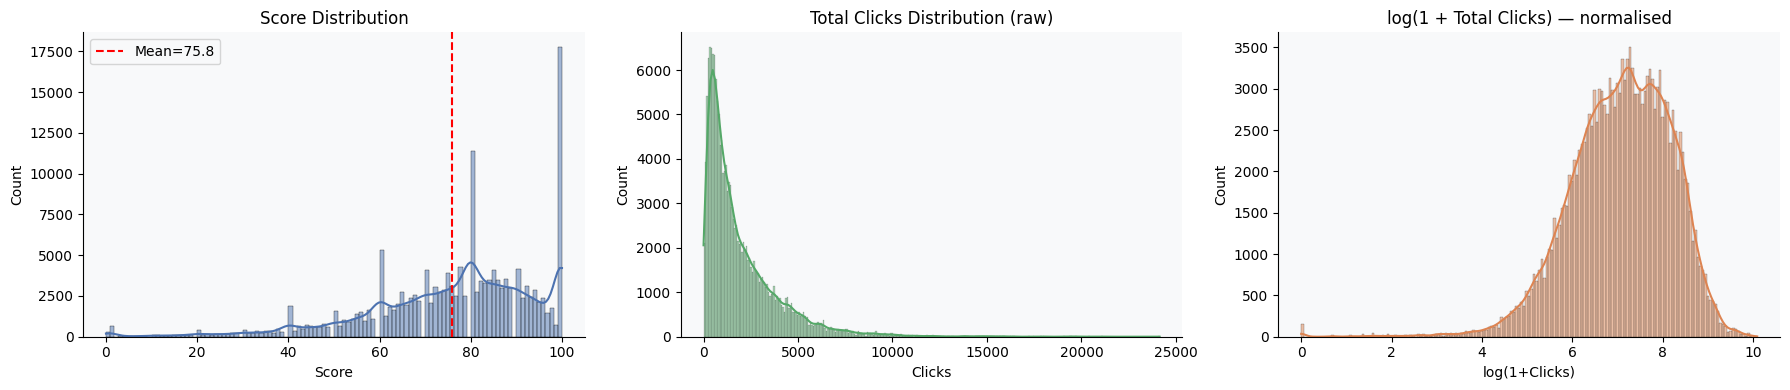

count    163752.000000
mean         75.809731
std          18.790558
min           0.000000
25%          65.000000
50%          80.000000
75%          90.000000
max         100.000000
Name: score, dtype: float64

Score skewness: -1.072
Clicks skewness: 2.415  →  log: -0.763


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(df["score"], kde=True, ax=axes[0], color="#4C72B0")
axes[0].set(title="Score Distribution", xlabel="Score", ylabel="Count")
axes[0].axvline(df["score"].mean(), color="red", ls="--", lw=1.5,
                label=f'Mean={df["score"].mean():.1f}')
axes[0].legend()

sns.histplot(df["total_clicks"], kde=True, ax=axes[1], color="#55A868")
axes[1].set(title="Total Clicks Distribution (raw)", xlabel="Clicks")

sns.histplot(np.log1p(df["total_clicks"]), kde=True, ax=axes[2], color="#DD8452")
axes[2].set(title="log(1 + Total Clicks) — normalised", xlabel="log(1+Clicks)")

plt.tight_layout()
plt.show()

print(df["score"].describe())
print(f"\nScore skewness: {df['score'].skew():.3f}")
print(f"Clicks skewness: {df['total_clicks'].skew():.3f}  →  log: {np.log1p(df['total_clicks']).skew():.3f}")


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 163752 entries, 0 to 163911
Data columns (total 65 columns):
 #   Column                                         Non-Null Count   Dtype  
---  ------                                         --------------   -----  
 0   date_submitted                                 163752 non-null  int64  
 1   is_banked                                      163752 non-null  int64  
 2   score                                          163752 non-null  float64
 3   date                                           163752 non-null  float64
 4   weight                                         163752 non-null  float64
 5   num_of_prev_attempts                           163752 non-null  int64  
 6   studied_credits                                163752 non-null  int64  
 7   module_presentation_length                     163752 non-null  int64  
 8   date_registration                              163752 non-null  float64
 9   total_clicks                              

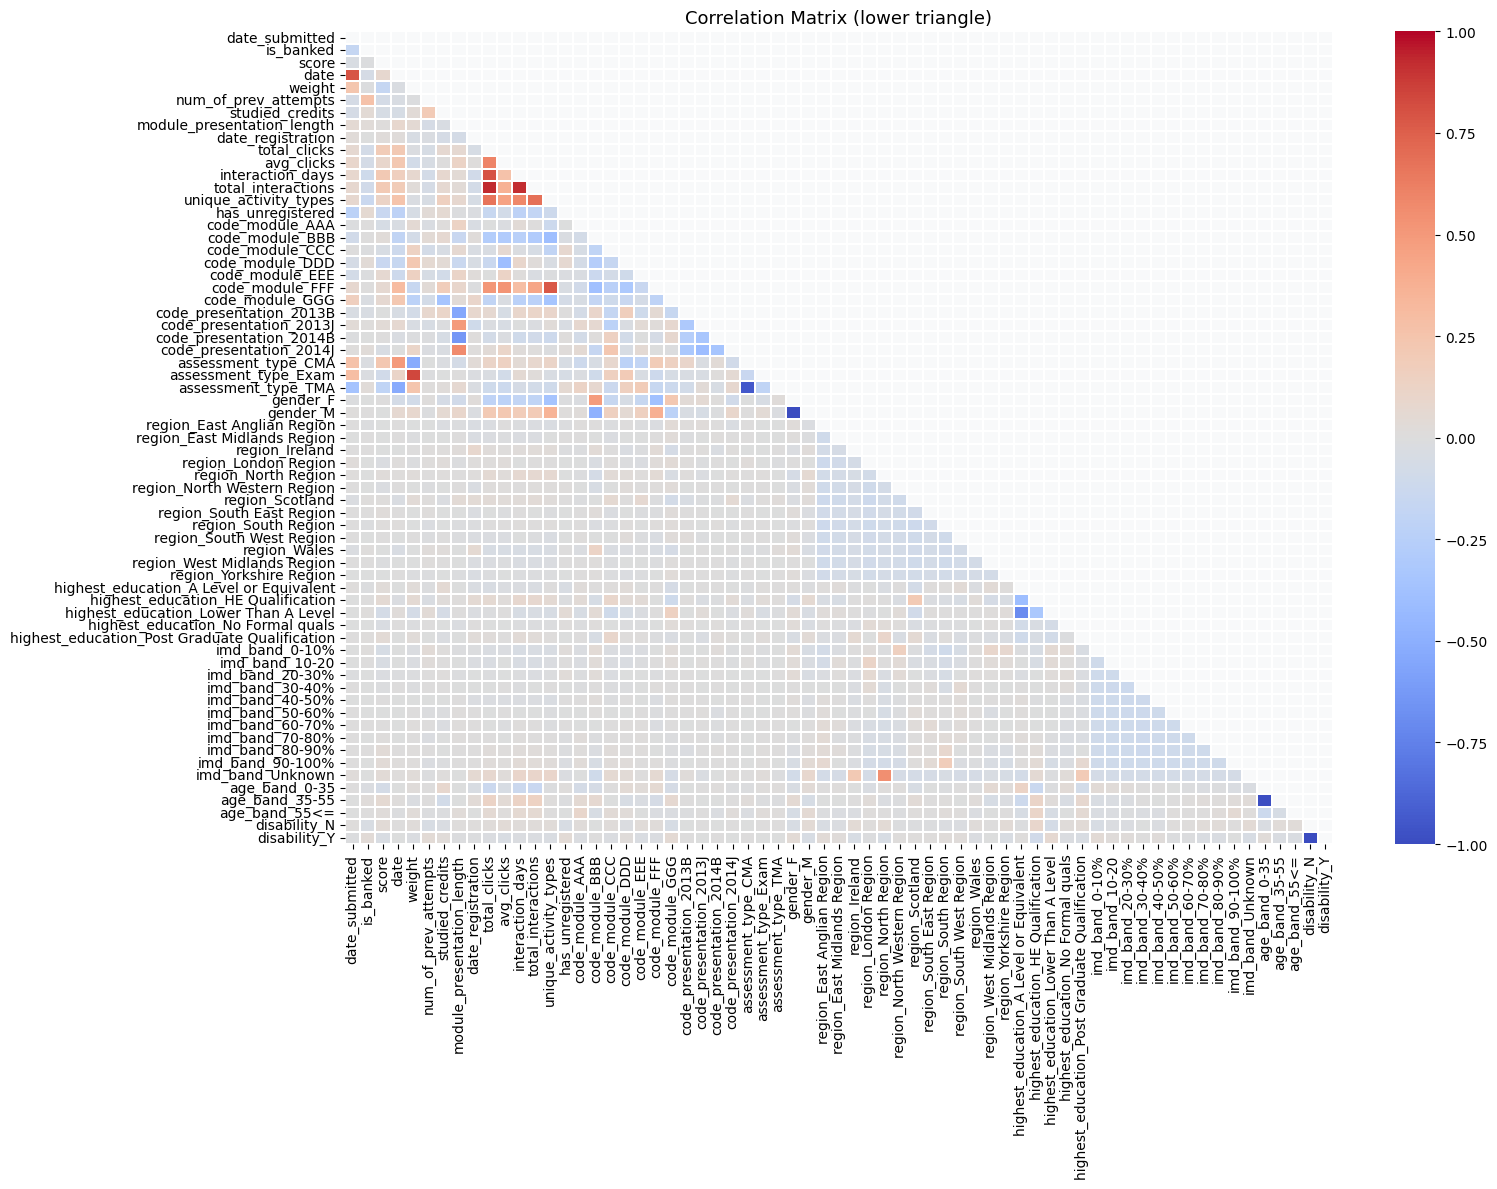

Top 15 correlations with score:
assessment_type_CMA                              0.230143
interaction_days                                 0.211965
total_interactions                               0.203636
total_clicks                                     0.188656
unique_activity_types                            0.119615
avg_clicks                                       0.093134
date                                             0.077539
code_module_FFF                                  0.068252
code_module_GGG                                  0.064623
code_module_EEE                                  0.062930
age_band_35-55                                   0.062299
highest_education_HE Qualification               0.048302
highest_education_Post Graduate Qualification    0.044503
imd_band_Unknown                                 0.038782
imd_band_90-100%                                 0.037435
Name: score, dtype: float64


In [17]:
id_cols = ["score", "id_student", "id_assessment"]
num_eda_cols = [c for c in df.select_dtypes(include=np.number).columns
                if c not in id_cols]
eda_scaler = StandardScaler()
df_eda = df.copy()
df_eda[num_eda_cols] = eda_scaler.fit_transform(df_eda[num_eda_cols])

corr = df_eda.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            linewidths=0.3, vmin=-1, vmax=1)
plt.title("Correlation Matrix (lower triangle)", fontsize=13)
plt.tight_layout()
plt.show()

corr_with_score = corr["score"].drop("score").sort_values(ascending=False)
print("Top 15 correlations with score:")
print(corr_with_score.head(15))


In [18]:
plot_cats = [c for c in cat_cols if c in df.columns]
for col in plot_cats:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(x=df[col].astype(int), y=df["score"], ax=ax, palette="Set2")
    ax.set(title=f"{col} vs Score (encoded)", xlabel=f"{col} (encoded)", ylabel="Score")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()


# 3) Feature Engineering :

In [19]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [20]:
print(df.shape)
print(df.info())
df.describe()

(163752, 65)
<class 'pandas.core.frame.DataFrame'>
Index: 163752 entries, 0 to 163911
Data columns (total 65 columns):
 #   Column                                         Non-Null Count   Dtype  
---  ------                                         --------------   -----  
 0   date_submitted                                 163752 non-null  int64  
 1   is_banked                                      163752 non-null  int64  
 2   score                                          163752 non-null  float64
 3   date                                           163752 non-null  float64
 4   weight                                         163752 non-null  float64
 5   num_of_prev_attempts                           163752 non-null  int64  
 6   studied_credits                                163752 non-null  int64  
 7   module_presentation_length                     163752 non-null  int64  
 8   date_registration                              163752 non-null  float64
 9   total_clicks                 

,date_submitted,is_banked,score,date,weight,num_of_prev_attempts,studied_credits,module_presentation_length,date_registration,total_clicks,...,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,imd_band_Unknown,age_band_0-35,age_band_35-55,age_band_55<=,disability_N,disability_Y
count,163752.000000,163752.000000,163752.000000,163752.000000,163752.000000,163752.000000,163752.000000,163752.000000,163752.000000,163752.000000,...,163752.000000,163752.000000,163752.000000,163752.000000,163752.000000,163752.000000,163752.000000,163752.000000,163752.000000,163752.000000
mean,115.989576,0.010858,75.809731,130.538882,12.758095,0.144566,76.755490,255.231289,-65.940587,1967.690056,...,0.092952,0.093727,0.090961,0.087199,0.044396,0.686105,0.307196,0.006699,0.912960,0.087040
std,71.471417,0.103634,18.790558,77.396008,17.921802,0.444821,37.351476,13.579911,47.012167,2029.101046,...,0.290365,0.291450,0.287554,0.282127,0.205975,0.464076,0.461333,0.081574,0.281895,0.281895
min,-11.000000,0.000000,0.000000,12.000000,0.000000,0.000000,30.000000,234.000000,-311.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51.000000,0.000000,65.000000,54.000000,0.000000,0.000000,60.000000,240.000000,-94.000000,585.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,116.000000,0.000000,80.000000,129.000000,9.000000,0.000000,60.000000,262.000000,-53.000000,1290.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,173.000000,0.000000,90.000000,208.000000,18.000000,0.000000,90.000000,268.000000,-29.000000,2696.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000
max,608.000000,1.000000,100.000000,261.000000,100.000000,6.000000,630.000000,269.000000,167.000000,24139.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Correlation of engineered features with assessmentClass:

engagement_ratio              0.2100
activity_diversity_ratio      0.1788
submission_offset             0.1741
submission_timing_ratio       0.1738
is_heavy_engager              0.1635
submitted_early               0.1430
click_per_day                 0.1101
avg_clicks_per_interaction    0.0957
has_prior_attempts            0.0667
low_engagement_late           0.0604
submitted_late                0.0419
engaged_but_late              0.0370
high_credit_load              0.0288
registration_offset           0.0185
Name: score, dtype: float64


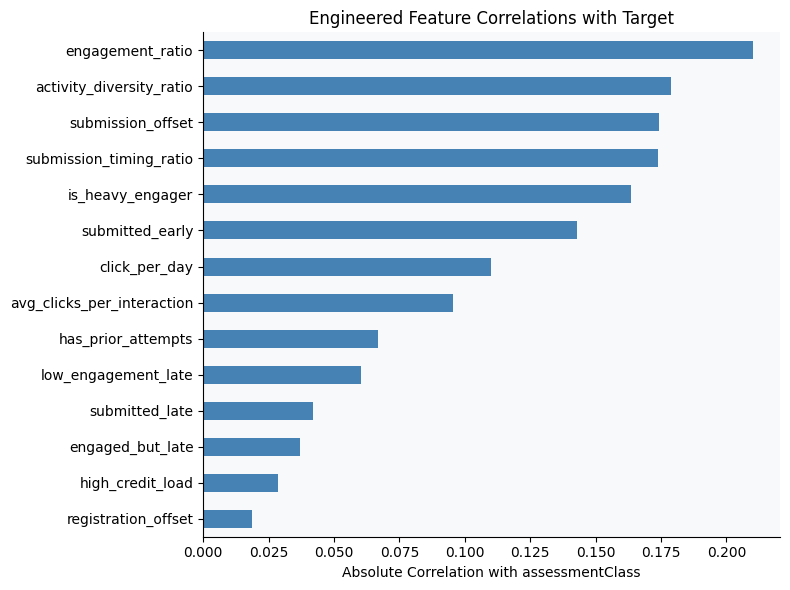

In [21]:
df['submission_offset']       = df['date_submitted'] - df['date']
df['submitted_late']          = (df['submission_offset'] > 0).astype(int)
df['submitted_early']         = (df['submission_offset'] < -3).astype(int)
df['submission_timing_ratio'] = df['submission_offset'] / (df['module_presentation_length'] + 1)

df['click_per_day']              = df['total_clicks'] / (df['interaction_days'] + 1)
df['avg_clicks_per_interaction'] = df['total_clicks'] / (df['total_interactions'] + 1)
df['activity_diversity_ratio']   = df['unique_activity_types'] / (df['total_interactions'] + 1)
df['engagement_ratio']           = (df['interaction_days'] / (df['module_presentation_length'] + 1)).clip(upper=1.0)

click_threshold      = df['total_clicks'].quantile(0.75)
df['is_heavy_engager'] = (df['total_clicks'] >= click_threshold).astype(int)

df['registration_offset'] = df['date_registration']
df['has_prior_attempts']  = (df['num_of_prev_attempts'] > 0).astype(int)
df['high_credit_load']    = (df['studied_credits'] > df['studied_credits'].median()).astype(int)

df['engaged_but_late']   = ((df['is_heavy_engager'] == 1) & (df['submitted_late'] == 1)).astype(int)
df['low_engagement_late']= ((df['is_heavy_engager'] == 0) & (df['submitted_late'] == 1)).astype(int)

df.drop(columns=['avg_clicks', 'total_interactions', 'interaction_days'], inplace=True)

new_features = [
    'submission_offset', 'submitted_late', 'submitted_early', 'submission_timing_ratio',
    'click_per_day', 'avg_clicks_per_interaction', 'activity_diversity_ratio',
    'engagement_ratio', 'is_heavy_engager', 'registration_offset',
    'has_prior_attempts', 'high_credit_load', 'engaged_but_late', 'low_engagement_late'
]

correlations = df[new_features + ['score']].corr()['score'].drop('score')
correlations = correlations.abs().sort_values(ascending=False)

print("Correlation of engineered features with assessmentClass:\n")
print(correlations.round(4))

correlations.plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel("Absolute Correlation with assessmentClass")
plt.title("Engineered Feature Correlations with Target")
plt.tight_layout()
plt.show()


In [22]:
# Save preprocessing values learned from training data
regression_preprocess_values = {
    "date_median": df["date"].median(),
    "date_registration_median": df["date_registration"].median(),
    "click_threshold": click_threshold,
    "studied_credits_median": df["studied_credits"].median()
}

with open(save_dir + "regression_preprocess_values.pkl", "wb") as f:
    pickle.dump(regression_preprocess_values, f)

print("Saved regression preprocessing values:")
print(regression_preprocess_values)

Saved regression preprocessing values:
{'date_median': 129.0, 'date_registration_median': -53.0, 'click_threshold': np.float64(2696.0), 'studied_credits_median': 60.0}


In [23]:
cols_to_drop = [
    "id_assessment", "id_student",

    "total_clicks", "avg_clicks_per_day", "total_interactions", "max_single_day_clicks",
    "clicks_per_day",

    "date_submitted",
    "date",
    "date_registration",

    "is_banked",
    "gender",
    "region",
]

cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print("Final feature set shape:", df.shape)
print("Features:", df.drop(columns=["score"]).columns.tolist())


Final feature set shape: (163752, 71)
Features: ['weight', 'num_of_prev_attempts', 'studied_credits', 'module_presentation_length', 'unique_activity_types', 'has_unregistered', 'code_module_AAA', 'code_module_BBB', 'code_module_CCC', 'code_module_DDD', 'code_module_EEE', 'code_module_FFF', 'code_module_GGG', 'code_presentation_2013B', 'code_presentation_2013J', 'code_presentation_2014B', 'code_presentation_2014J', 'assessment_type_CMA', 'assessment_type_Exam', 'assessment_type_TMA', 'gender_F', 'gender_M', 'region_East Anglian Region', 'region_East Midlands Region', 'region_Ireland', 'region_London Region', 'region_North Region', 'region_North Western Region', 'region_Scotland', 'region_South East Region', 'region_South Region', 'region_South West Region', 'region_Wales', 'region_West Midlands Region', 'region_Yorkshire Region', 'highest_education_A Level or Equivalent', 'highest_education_HE Qualification', 'highest_education_Lower Than A Level', 'highest_education_No Formal quals', '

In [24]:
# Save final regression feature columns
regression_feature_columns = df.drop("score", axis=1).columns.tolist()

with open(save_dir + "regression_feature_columns.pkl", "wb") as f:
    pickle.dump(regression_feature_columns, f)

print("Saved regression feature columns:", len(regression_feature_columns))

Saved regression feature columns: 70


# 4 ) Models

In [25]:
X = df.drop("score", axis=1)
X = X.reindex(columns=regression_feature_columns, fill_value=0)
y = df["score"]

# 70 / 15 / 15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Train : {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Val   : {X_val.shape[0]:,} rows  ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Features: {X.shape[1]}")


Train : 114,626 rows  (70%)
Val   : 24,563 rows  (15%)
Test  : 24,563 rows  (15%)
Features: 70


In [26]:
pipe_scaler = StandardScaler()
X_train_s = pd.DataFrame(pipe_scaler.fit_transform(X_train), columns=X_train.columns)
X_val_s   = pd.DataFrame(pipe_scaler.transform(X_val),       columns=X_val.columns)
X_test_s  = pd.DataFrame(pipe_scaler.transform(X_test),      columns=X_test.columns)

print("Scaling applied on train only — no leakage ")


Scaling applied on train only — no leakage 


In [27]:
ridge = Ridge(alpha=10.0)
lasso = Lasso(alpha=1.0, max_iter=5000)
gb    = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                   max_depth=4, subsample=0.8,
                                   min_samples_leaf=20, random_state=42)
rf    = RandomForestRegressor(n_estimators=200, max_depth=8,
                               min_samples_leaf=20, random_state=42, n_jobs=-1)
dt    = DecisionTreeRegressor(max_depth=6, min_samples_leaf=25, random_state=42)

model_names = ["Ridge", "Lasso", "Gradient Boosting", "Random Forest", "Decision Tree"]
models_list = [ridge, lasso, gb, rf, dt]

val_preds = []
for name, model in zip(model_names, models_list):
    model.fit(X_train_s, y_train)
    val_preds.append(model.predict(X_val_s))
    print(f"  {name:22s} trained  |  Val R² = {r2_score(y_val, val_preds[-1]):.4f}")

ridge_val, lasso_val, gb_val, rf_val, dt_val = val_preds


  Ridge                  trained  |  Val R² = 0.1619
  Lasso                  trained  |  Val R² = 0.1218
  Gradient Boosting      trained  |  Val R² = 0.2757
  Random Forest          trained  |  Val R² = 0.2393
  Decision Tree          trained  |  Val R² = 0.1998


# 5)  Evaluation, Visualization & Report

In [28]:
def eval_metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)

    return {
        "Model": name,
        "R²":    round(r2_score(y_true, y_pred), 4),
        "MSE":   round(mse, 2),
        "RMSE":  round(np.sqrt(mse), 2),
        "MAE":   round(mean_absolute_error(y_true, y_pred), 2),
    }

val_metrics = pd.DataFrame([
    eval_metrics(y_val, p, n) for n, p in zip(model_names, val_preds)
]).sort_values("R²", ascending=False).reset_index(drop=True)

print("── Validation Set ──")
print(val_metrics.to_string(index=False))

# Select best model for final test-set evaluation
best_name  = val_metrics.iloc[0]["Model"]
best_model = dict(zip(model_names, models_list))[best_name]
y_test_pred = best_model.predict(X_test_s)

test_mse = mean_squared_error(y_test, y_test_pred)

print(f"\n── Test Set ({best_name}) ──")
print(f"  R²   = {r2_score(y_test, y_test_pred):.4f}")
print(f"  MSE  = {test_mse:.2f}")
print(f"  RMSE = {np.sqrt(test_mse):.2f}")
print(f"  MAE  = {mean_absolute_error(y_test, y_test_pred):.2f}")


── Validation Set ──
            Model     R²    MSE  RMSE   MAE
Gradient Boosting 0.2757 253.13 15.91 12.11
    Random Forest 0.2393 265.86 16.31 12.44
    Decision Tree 0.1998 279.67 16.72 12.77
            Ridge 0.1619 292.88 17.11 13.11
            Lasso 0.1218 306.91 17.52 13.43

── Test Set (Gradient Boosting) ──
  R²   = 0.2755
  MSE  = 254.67
  RMSE = 15.96
  MAE  = 12.11


In [29]:
# Save best regression model and preprocessing objects
with open(save_dir + "best_regression_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open(save_dir + "regression_scaler.pkl", "wb") as f:
    pickle.dump(pipe_scaler, f)

with open(save_dir + "regression_feature_columns.pkl", "wb") as f:
    pickle.dump(regression_feature_columns, f)

with open(save_dir + "regression_preprocess_values.pkl", "wb") as f:
    pickle.dump(regression_preprocess_values, f)

print("\nSaved best regression model and preprocessing objects.")
print("Best regression model:", best_name)


Saved best regression model and preprocessing objects.
Best regression model: Gradient Boosting


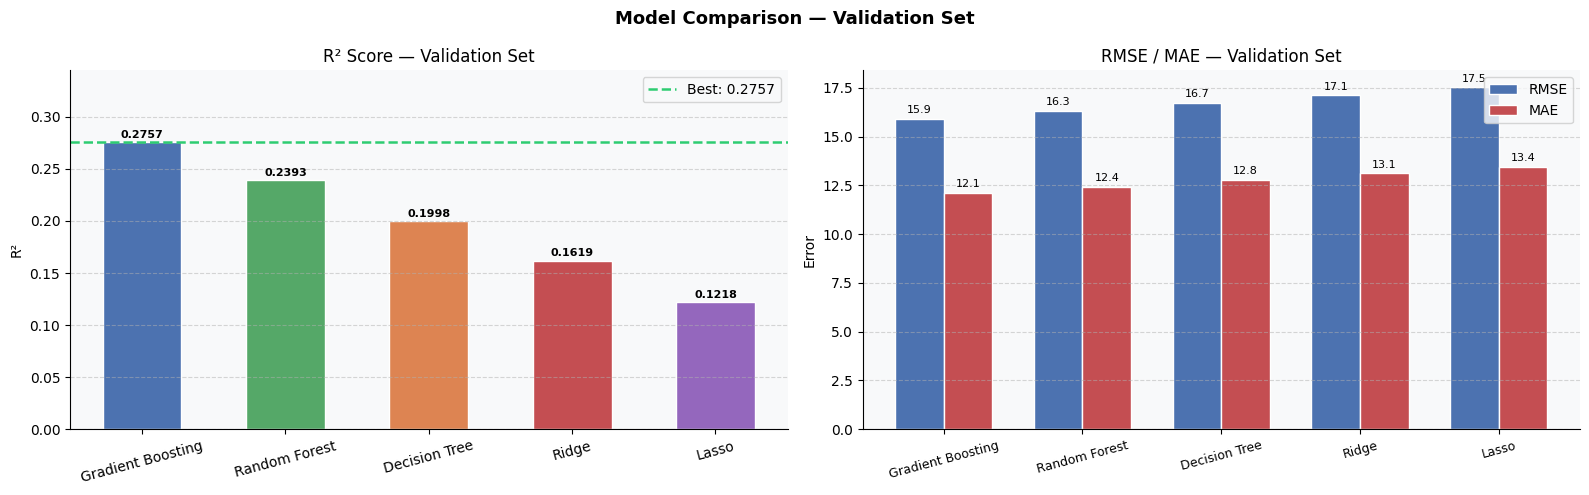

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(val_metrics["Model"], val_metrics["R²"],
            color=COLORS[:len(val_metrics)], width=0.55, edgecolor="white")
axes[0].axhline(val_metrics["R²"].max(), color="#2ECC71", lw=1.8, ls="--",
                label=f'Best: {val_metrics["R²"].max():.4f}')
for bar, val in zip(axes[0].patches, val_metrics["R²"]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.004,
                 f"{val:.4f}", ha="center", fontsize=8, fontweight="bold")
axes[0].set(title="R² Score — Validation Set", ylabel="R²",
            ylim=(0, val_metrics["R²"].max() * 1.25))
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend(); axes[0].grid(axis="y", ls="--", alpha=0.5)

x = np.arange(len(val_metrics)); w = 0.35
for offset, col, color in zip([-w/2, w/2], ["RMSE", "MAE"], ["#4C72B0", "#C44E52"]):
    bars = axes[1].bar(x + offset, val_metrics[col], w,
                       label=col, color=color, edgecolor="white")
    for b in bars:
        axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                     f"{b.get_height():.1f}", ha="center", fontsize=8)

axes[1].set_xticks(x)
axes[1].set_xticklabels(val_metrics["Model"], fontsize=9, rotation=15)
axes[1].set(title="RMSE / MAE — Validation Set", ylabel="Error")
axes[1].legend(); axes[1].grid(axis="y", ls="--", alpha=0.5)

plt.suptitle("Model Comparison — Validation Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


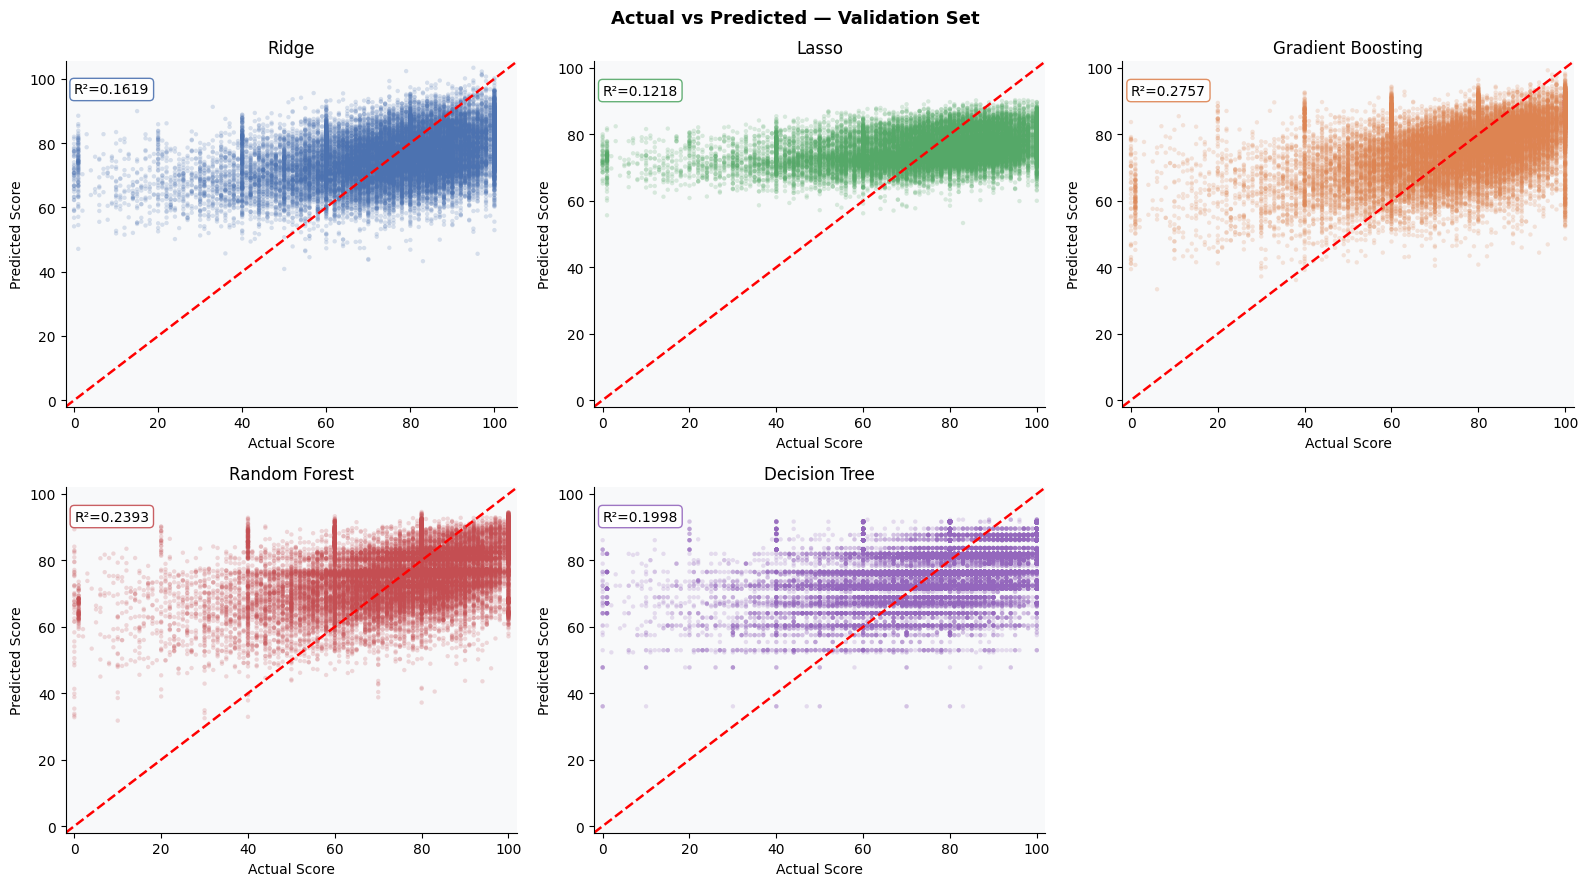

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()

for ax, name, preds, color in zip(axes_flat, model_names, val_preds, COLORS):
    r2  = r2_score(y_val, preds)
    lo  = float(min(np.min(y_val), np.min(preds))) - 2
    hi  = float(max(np.max(y_val), np.max(preds))) + 2

    ax.scatter(y_val, preds, alpha=0.2, s=10, color=color, edgecolors="none")
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.8)
    ax.set(xlim=[lo, hi], ylim=[lo, hi], title=name,
           xlabel="Actual Score", ylabel="Predicted Score")
    ax.text(lo + 2, hi - 10, f"R²={r2:.4f}", fontsize=10,
            bbox=dict(boxstyle="round", fc="white", ec=color, alpha=0.9))

if len(model_names) < len(axes_flat):
    for ax in axes_flat[len(model_names):]:
        ax.set_visible(False)

fig.suptitle("Actual vs Predicted — Validation Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


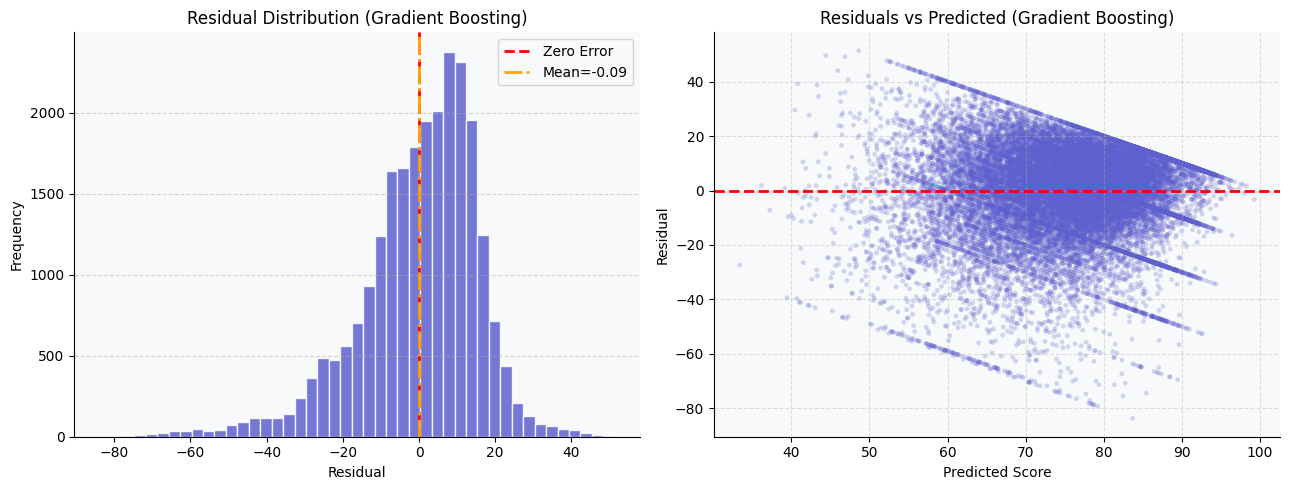

In [32]:
best_val_pred = dict(zip(model_names, val_preds))[best_name]
residuals = np.asarray(y_val) - np.asarray(best_val_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(residuals, bins=45, color="#5E60CE", edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="red", lw=2, ls="--", label="Zero Error")
axes[0].axvline(residuals.mean(), color="orange", lw=2, ls="-.",
                label=f"Mean={residuals.mean():.2f}")
axes[0].set(title=f"Residual Distribution ({best_name})",
            xlabel="Residual", ylabel="Frequency")
axes[0].legend(); axes[0].grid(axis="y", ls="--", alpha=0.5)

axes[1].scatter(best_val_pred, residuals, alpha=0.25, s=12,
                color="#5E60CE", edgecolors="none")
axes[1].axhline(0, color="red", lw=2, ls="--")
axes[1].set(title=f"Residuals vs Predicted ({best_name})",
            xlabel="Predicted Score", ylabel="Residual")
axes[1].grid(ls="--", alpha=0.4)

plt.tight_layout()
plt.show()


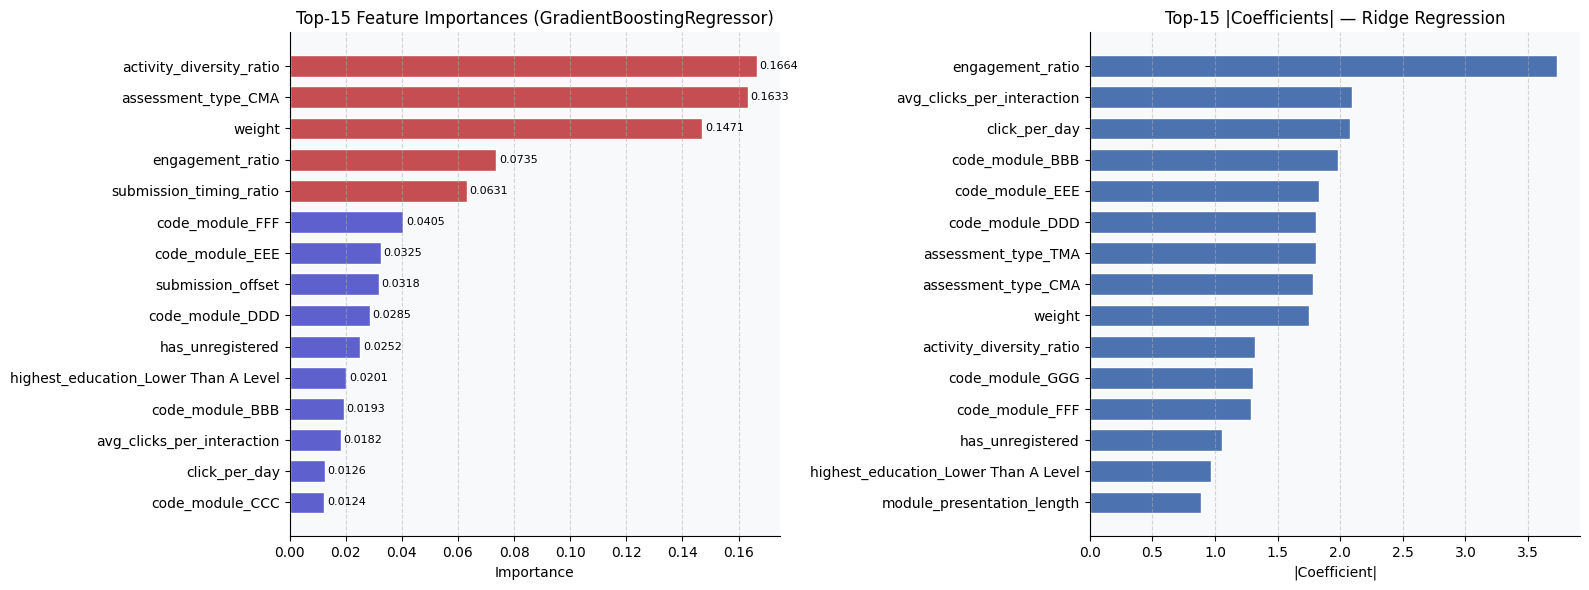

In [33]:
tree_model = gb if hasattr(gb, "feature_importances_") else rf
feat_df = (
    pd.DataFrame({"Feature":    X_train_s.columns,
                  "Importance": tree_model.feature_importances_})
    .sort_values("Importance", ascending=True)
    .tail(15)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bar_colors = ["#C44E52" if v > 0.05 else "#5E60CE" for v in feat_df["Importance"]]
bars = axes[0].barh(feat_df["Feature"], feat_df["Importance"],
                    color=bar_colors, edgecolor="white", height=0.7)
for b in bars:
    axes[0].text(b.get_width() + 0.001, b.get_y() + b.get_height()/2,
                 f"{b.get_width():.4f}", va="center", fontsize=8)
axes[0].set(title=f"Top-15 Feature Importances ({type(tree_model).__name__})",
            xlabel="Importance")
axes[0].grid(axis="x", ls="--", alpha=0.5)

ridge_coef = pd.Series(np.abs(ridge.coef_), index=X_train_s.columns)
ridge_top  = ridge_coef.sort_values(ascending=True).tail(15)
axes[1].barh(ridge_top.index, ridge_top.values, color="#4C72B0",
             edgecolor="white", height=0.7)
axes[1].set(title="Top-15 |Coefficients| — Ridge Regression",
            xlabel="|Coefficient|")
axes[1].grid(axis="x", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()


# Cross-Validation

5-Fold Cross-Validation (on scaled training data):
            Model  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean R²    Std
Gradient Boosting  0.2838  0.2847  0.2895  0.2871  0.2854   0.2861 0.0020
    Random Forest  0.2478  0.2490  0.2526  0.2534  0.2533   0.2512 0.0023
    Decision Tree  0.2079  0.2071  0.2124  0.2134  0.2136   0.2109 0.0028
            Ridge  0.1762  0.1711  0.1734  0.1710  0.1710   0.1725 0.0020
            Lasso  0.1267  0.1238  0.1235  0.1237  0.1259   0.1247 0.0013


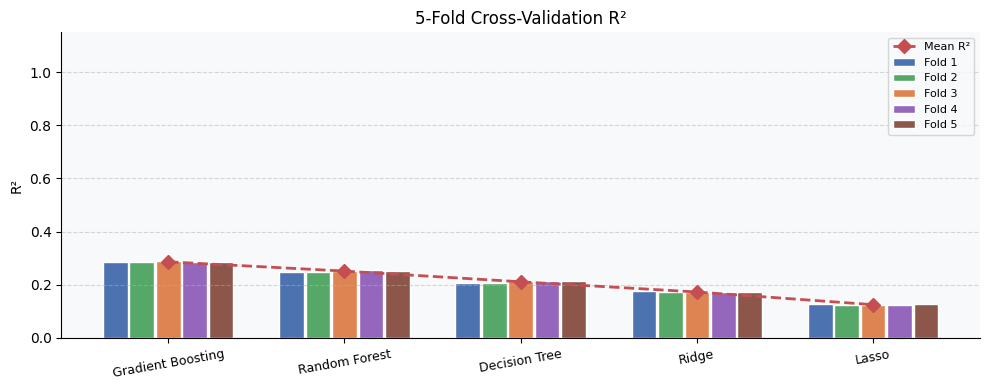

In [34]:
cv_rows = []
for name, model in zip(model_names, models_list):
    scores = cross_val_score(model, X_train_s, y_train,
                             cv=5, scoring="r2", n_jobs=-1)
    cv_rows.append({
        "Model":   name,
        **{f"Fold {i+1}": round(s, 4) for i, s in enumerate(scores)},
        "Mean R²": round(scores.mean(), 4),
        "Std":     round(scores.std(),  4),
    })

cv_df = pd.DataFrame(cv_rows).sort_values("Mean R²", ascending=False)
print("5-Fold Cross-Validation (on scaled training data):")
print(cv_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
fold_cols   = [c for c in cv_df.columns if c.startswith("Fold")]
fold_colors = ["#4C72B0","#55A868","#DD8452","#9467BD","#8C564B"]
x = np.arange(len(cv_df))
for i, (fold, fc) in enumerate(zip(fold_cols, fold_colors)):
    ax.bar(x + (i - len(fold_cols)/2 + 0.5) * 0.15,
           cv_df[fold], 0.14, label=fold, color=fc, edgecolor="white")
ax.plot(x, cv_df["Mean R²"], "D--", color="#C44E52", lw=2, ms=7, label="Mean R²")
ax.set_xticks(x); ax.set_xticklabels(cv_df["Model"], fontsize=9, rotation=10)
ax.set(title="5-Fold Cross-Validation R²", ylabel="R²", ylim=(0, 1.15))
ax.legend(fontsize=8); ax.grid(axis="y", ls="--", alpha=0.5)
plt.tight_layout(); plt.show()


#  Final Test Set Evaluation

All Models — Test Set:
            Model     R²    MSE  RMSE   MAE
Gradient Boosting 0.2755 254.67 15.96 12.11
    Random Forest 0.2401 267.12 16.34 12.42
    Decision Tree 0.1999 281.24 16.77 12.73
            Ridge 0.1600 295.27 17.18 13.11
            Lasso 0.1188 309.78 17.60 13.47


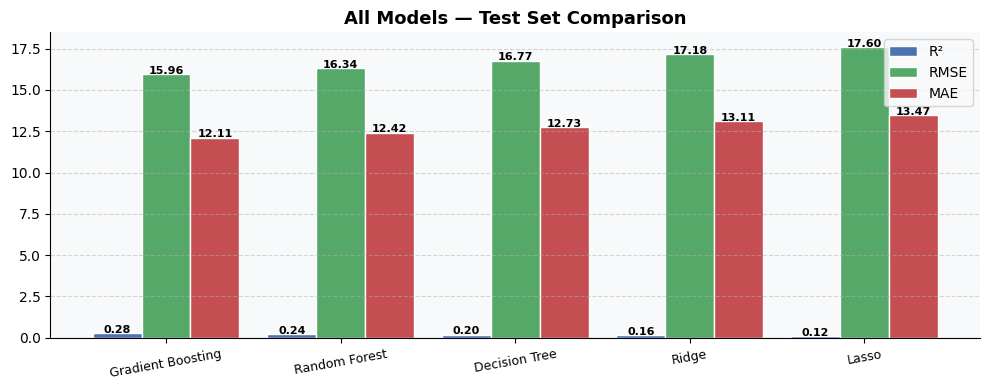

In [35]:
test_rows = []
for name, model in zip(model_names, models_list):
    preds = model.predict(X_test_s)
    test_rows.append(eval_metrics(y_test, preds, name))

res_df = pd.DataFrame(test_rows).sort_values("R²", ascending=False)
print("All Models — Test Set:")
print(res_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(res_df)); w = 0.28
for offset, col, color in zip([-w, 0, w], ["R²", "RMSE", "MAE"],
                               ["#4C72B0", "#55A868", "#C44E52"]):
    bars = ax.bar(x + offset, res_df[col], w, label=col,
                  color=color, edgecolor="white")
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f"{b.get_height():.2f}", ha="center", fontsize=8, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(res_df["Model"], fontsize=9, rotation=10)
ax.set_title("All Models — Test Set Comparison", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(axis="y", ls="--", alpha=0.5)
plt.tight_layout(); plt.show()


# Overfitting Analysis & Learning Curve

            Model  Train R²  Val R²  Test R²  Train-Test Gap
            Ridge    0.1736  0.1619   0.1600          0.0136
            Lasso    0.1249  0.1218   0.1188          0.0061
Gradient Boosting    0.3025  0.2757   0.2755          0.0270
    Random Forest    0.2718  0.2393   0.2401          0.0317
    Decision Tree    0.2195  0.1998   0.1999          0.0196


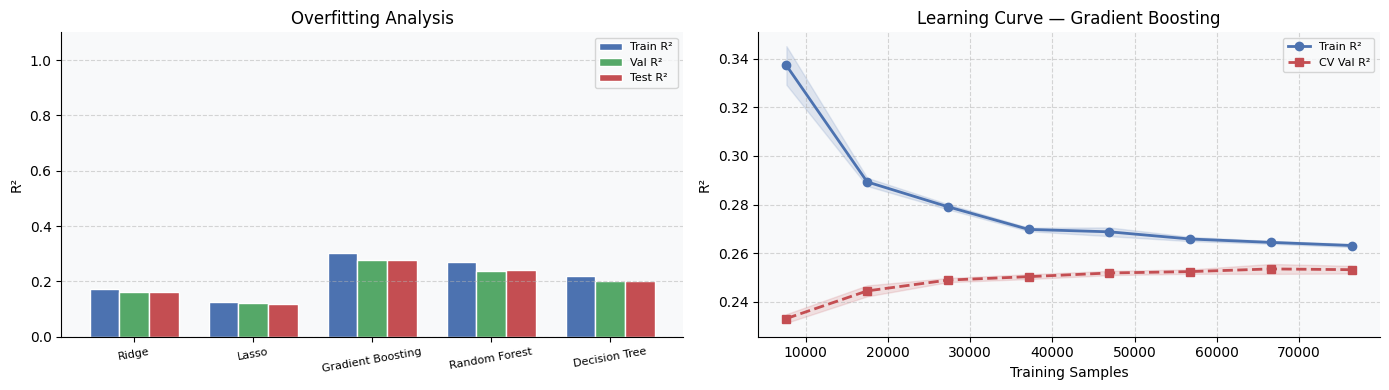

In [36]:
ov_rows = []
for name, model, vp in zip(model_names, models_list, val_preds):
    ov_rows.append({
        "Model":    name,
        "Train R²": round(r2_score(y_train, model.predict(X_train_s)), 4),
        "Val R²":   round(r2_score(y_val, vp), 4),
        "Test R²":  round(r2_score(y_test, model.predict(X_test_s)), 4),
    })

ov = pd.DataFrame(ov_rows)
ov["Train-Test Gap"] = (ov["Train R²"] - ov["Test R²"]).round(4)
print(ov.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x, w = np.arange(len(ov)), 0.25
for off, col, c in zip([-w, 0, w],
                        ["Train R²", "Val R²", "Test R²"],
                        ["#4C72B0", "#55A868", "#C44E52"]):
    axes[0].bar(x + off, ov[col], w, label=col, color=c, edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(ov["Model"], fontsize=8, rotation=10)
axes[0].set(title="Overfitting Analysis", ylabel="R²", ylim=(0, 1.1))
axes[0].legend(fontsize=8); axes[0].grid(axis="y", ls="--", alpha=0.5)

train_sizes, train_sc, val_sc = learning_curve(
    GradientBoostingRegressor(n_estimators=100, max_depth=4,
                              learning_rate=0.05, random_state=42),
    X_train_s, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3, scoring="r2", n_jobs=-1
)

axes[1].plot(train_sizes, train_sc.mean(axis=1), "o-", color="#4C72B0", lw=2, label="Train R²")
axes[1].fill_between(train_sizes,
                     train_sc.mean(axis=1) - train_sc.std(axis=1),
                     train_sc.mean(axis=1) + train_sc.std(axis=1),
                     alpha=0.15, color="#4C72B0")
axes[1].plot(train_sizes, val_sc.mean(axis=1), "s--", color="#C44E52", lw=2, label="CV Val R²")
axes[1].fill_between(train_sizes,
                     val_sc.mean(axis=1) - val_sc.std(axis=1),
                     val_sc.mean(axis=1) + val_sc.std(axis=1),
                     alpha=0.15, color="#C44E52")
axes[1].set(title="Learning Curve — Gradient Boosting",
            xlabel="Training Samples", ylabel="R²")
axes[1].legend(fontsize=8); axes[1].grid(ls="--", alpha=0.5)
plt.tight_layout(); plt.show()


# Test Script

In [37]:
def build_regression_test_dataframe(test_path):
    assessments = pd.read_csv(test_path + "assessments.csv")
    courses = pd.read_csv(test_path + "courses.csv")
    studentAssessment = pd.read_csv(test_path + "StudentAssesments.csv")
    studentInfo = pd.read_csv(test_path + "studentInfo.csv")
    studentRegistration = pd.read_csv(test_path + "studentRegistration.csv")
    studentVle = pd.read_csv(test_path + "studentVle.csv")
    vle = pd.read_csv(test_path + "vle.csv")

    studentVle_full = studentVle.merge(
        vle,
        on=["id_site", "code_module", "code_presentation"]
    )

    studentVle_agg = studentVle_full.groupby(
        ["code_module", "code_presentation", "id_student"]
    ).agg(
        total_clicks=("sum_click", "sum"),
        avg_clicks=("sum_click", "mean"),
        interaction_days=("date", "nunique"),
        total_interactions=("id_site", "count"),
        unique_activity_types=("activity_type", "nunique")
    ).reset_index()

    df = studentAssessment.merge(
        assessments,
        on="id_assessment",
        how="left"
    )

    df = df.merge(
        studentInfo,
        on=["id_student", "code_module", "code_presentation"],
        how="left"
    )

    df = df.merge(
        courses,
        on=["code_module", "code_presentation"],
        how="left"
    )

    df = df.merge(
        studentRegistration,
        on=["id_student", "code_module", "code_presentation"],
        how="left"
    )

    df = df.merge(
        studentVle_agg,
        on=["id_student", "code_module", "code_presentation"],
        how="left"
    )

    return df

In [38]:
def preprocess_regression_unseen(test_df):
    test_df = test_df.copy()

    test_df.replace("?", np.nan, inplace=True)

    y_true = None
    if "score" in test_df.columns:
        y_true = pd.to_numeric(test_df["score"], errors="coerce")
        test_df.drop(columns=["score"], inplace=True)

    if "date_unregistration" in test_df.columns:
        test_df["has_unregistered"] = test_df["date_unregistration"].notna().astype(int)
    else:
        test_df["has_unregistered"] = 0

    drop_cols = ["id_assessment", "id_student", "date_unregistration"]
    test_df.drop(columns=[c for c in drop_cols if c in test_df.columns], inplace=True)

    for c in ["date", "date_registration"]:
        if c in test_df.columns:
            test_df[c] = pd.to_numeric(test_df[c], errors="coerce")
        else:
            test_df[c] = np.nan

    test_df["date"] = test_df["date"].fillna(regression_preprocess_values["date_median"])
    test_df["date_registration"] = test_df["date_registration"].fillna(
        regression_preprocess_values["date_registration_median"]
    )

    if "imd_band" in test_df.columns:
        test_df["imd_band"] = test_df["imd_band"].fillna("Unknown")

    vle_cols = [
        "total_clicks",
        "avg_clicks",
        "interaction_days",
        "total_interactions",
        "unique_activity_types"
    ]

    for c in vle_cols:
        if c in test_df.columns:
            test_df[c] = test_df[c].fillna(0)
        else:
            test_df[c] = 0

    cat_cols = test_df.select_dtypes(include="object").columns.tolist()
    test_df = pd.get_dummies(test_df, columns=cat_cols)

    test_df["submission_offset"] = test_df["date_submitted"] - test_df["date"]
    test_df["submitted_late"] = (test_df["submission_offset"] > 0).astype(int)
    test_df["submitted_early"] = (test_df["submission_offset"] < -3).astype(int)
    test_df["submission_timing_ratio"] = test_df["submission_offset"] / (
        test_df["module_presentation_length"] + 1
    )

    test_df["click_per_day"] = test_df["total_clicks"] / (test_df["interaction_days"] + 1)
    test_df["avg_clicks_per_interaction"] = test_df["total_clicks"] / (
        test_df["total_interactions"] + 1
    )
    test_df["activity_diversity_ratio"] = test_df["unique_activity_types"] / (
        test_df["total_interactions"] + 1
    )
    test_df["engagement_ratio"] = (
        test_df["interaction_days"] / (test_df["module_presentation_length"] + 1)
    ).clip(upper=1.0)

    test_df["is_heavy_engager"] = (
        test_df["total_clicks"] >= regression_preprocess_values["click_threshold"]
    ).astype(int)

    test_df["registration_offset"] = test_df["date_registration"]
    test_df["has_prior_attempts"] = (test_df["num_of_prev_attempts"] > 0).astype(int)
    test_df["high_credit_load"] = (
        test_df["studied_credits"] > regression_preprocess_values["studied_credits_median"]
    ).astype(int)

    test_df["engaged_but_late"] = (
        (test_df["is_heavy_engager"] == 1) & (test_df["submitted_late"] == 1)
    ).astype(int)

    test_df["low_engagement_late"] = (
        (test_df["is_heavy_engager"] == 0) & (test_df["submitted_late"] == 1)
    ).astype(int)

    drop_same_as_training = [
        "avg_clicks",
        "total_interactions",
        "interaction_days",
        "id_assessment",
        "id_student",
        "total_clicks",
        "avg_clicks_per_day",
        "max_single_day_clicks",
        "clicks_per_day",
        "date_submitted",
        "date",
        "date_registration",
        "is_banked",
        "gender",
        "region"
    ]

    test_df.drop(
        columns=[c for c in drop_same_as_training if c in test_df.columns],
        inplace=True
    )

    test_df = test_df.reindex(columns=regression_feature_columns, fill_value=0)

    test_df = test_df.fillna(0)

    return test_df, y_true

In [39]:
# Load saved regression objects
regression_model = pickle.load(open(save_dir + "best_regression_model.pkl", "rb"))
regression_scaler = pickle.load(open(save_dir + "regression_scaler.pkl", "rb"))
regression_feature_columns = pickle.load(open(save_dir + "regression_feature_columns.pkl", "rb"))
regression_preprocess_values = pickle.load(open(save_dir + "regression_preprocess_values.pkl", "rb"))

print("Loaded regression model and preprocessing objects.")

Loaded regression model and preprocessing objects.


In [40]:
# ============================================================
# PRACTICAL REGRESSION TEST CODE - DO NOT RUN NOW
# Run this only tomorrow when the TA gives you the unseen 7 CSV files.
# Change test_path to the folder containing the 7 unseen CSV files.
# ============================================================

# test_path = "/content/drive/MyDrive/ML Project/unseen_test/"

# # 1. Build merged dataframe from the 7 unseen CSVs
# test_df = build_regression_test_dataframe(test_path)

# # 2. Apply same preprocessing as training
# X_unseen_raw, y_true = preprocess_regression_unseen(test_df)

# # 3. Scale using saved scaler
# X_unseen_scaled = regression_scaler.transform(X_unseen_raw)

# # 4. Predict using saved model
# pred_score = regression_model.predict(X_unseen_scaled)

# # 5. Show predictions
# regression_results = pd.DataFrame({
#     "predicted_score": pred_score
# })

# print(regression_results.head())
# print("\nPrediction summary:")
# print(regression_results["predicted_score"].describe())

# # 6. If target exists, show MSE and R²
# if y_true is not None:
#     valid_mask = y_true.notna()
#     y_true_valid = y_true[valid_mask]
#     pred_valid = pred_score[valid_mask]

#     mse = mean_squared_error(y_true_valid, pred_valid)
#     r2 = r2_score(y_true_valid, pred_valid)

#     print("Regression MSE:", mse)
#     print("Regression R²:", r2)
# else:
#     print("No score column found in unseen test data, so only predictions were generated.")

In [41]:
expected_files = [
    "best_regression_model.pkl",
    "regression_scaler.pkl",
    "regression_feature_columns.pkl",
    "regression_preprocess_values.pkl"
]

for file in expected_files:
    full_path = save_dir + file
    print(file, "FOUND" if os.path.exists(full_path) else "MISSING")

best_regression_model.pkl FOUND
regression_scaler.pkl FOUND
regression_feature_columns.pkl FOUND
regression_preprocess_values.pkl FOUND


In [42]:
# Check saved regression objects on internal test set

loaded_regression_model = pickle.load(open(save_dir + "best_regression_model.pkl", "rb"))
loaded_regression_scaler = pickle.load(open(save_dir + "regression_scaler.pkl", "rb"))
loaded_regression_feature_columns = pickle.load(open(save_dir + "regression_feature_columns.pkl", "rb"))
loaded_regression_preprocess_values = pickle.load(open(save_dir + "regression_preprocess_values.pkl", "rb"))

X_check = X_test.copy()
X_check = X_check.reindex(columns=loaded_regression_feature_columns, fill_value=0)
X_check_scaled = loaded_regression_scaler.transform(X_check)

pred_check = loaded_regression_model.predict(X_check_scaled)

mse_check = mean_squared_error(y_test, pred_check)
r2_check = r2_score(y_test, pred_check)

print("Predictions shape:", pred_check.shape)
print("First 10 predicted scores:", pred_check[:10])
print("MSE using loaded model:", mse_check)
print("R² using loaded model:", r2_check)

Predictions shape: (24563,)
First 10 predicted scores: [71.86423258 83.4574159  89.55007094 77.83063826 87.16937246 88.95912999
 88.97044754 64.86064437 87.54621738 71.85718368]
MSE using loaded model: 254.6677404394798
R² using loaded model: 0.27553578873789764
